In [1]:
# importing all the libraries i need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

In [2]:
# setting up plot style as per lab requirement
# 600 dpi, Times New Roman font, save as .eps
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

# just a small helper so i dont have to type the same savefig line everytime
def save_plot(filename):
    plt.savefig(f"{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    print(f"saved {filename}.eps")



In [3]:
# loading CIFAR-10 directly through keras
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("training data shape:", X_train.shape)
print("training labels shape:", y_train.shape)
print("testing data shape :", X_test.shape)
print("testing labels shape :", y_test.shape)

training data shape: (50000, 32, 32, 3)
training labels shape: (50000, 1)
testing data shape : (10000, 32, 32, 3)
testing labels shape : (10000, 1)


c:\Users\Kishore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
# normalizing pixel values to [0,1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# one hot encoding the labels since we are using categorical crossentropy
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape :", y_test_cat.shape)

y_train_cat shape: (50000, 10)
y_test_cat shape : (10000, 10)


saved sample_cifar10_images.eps


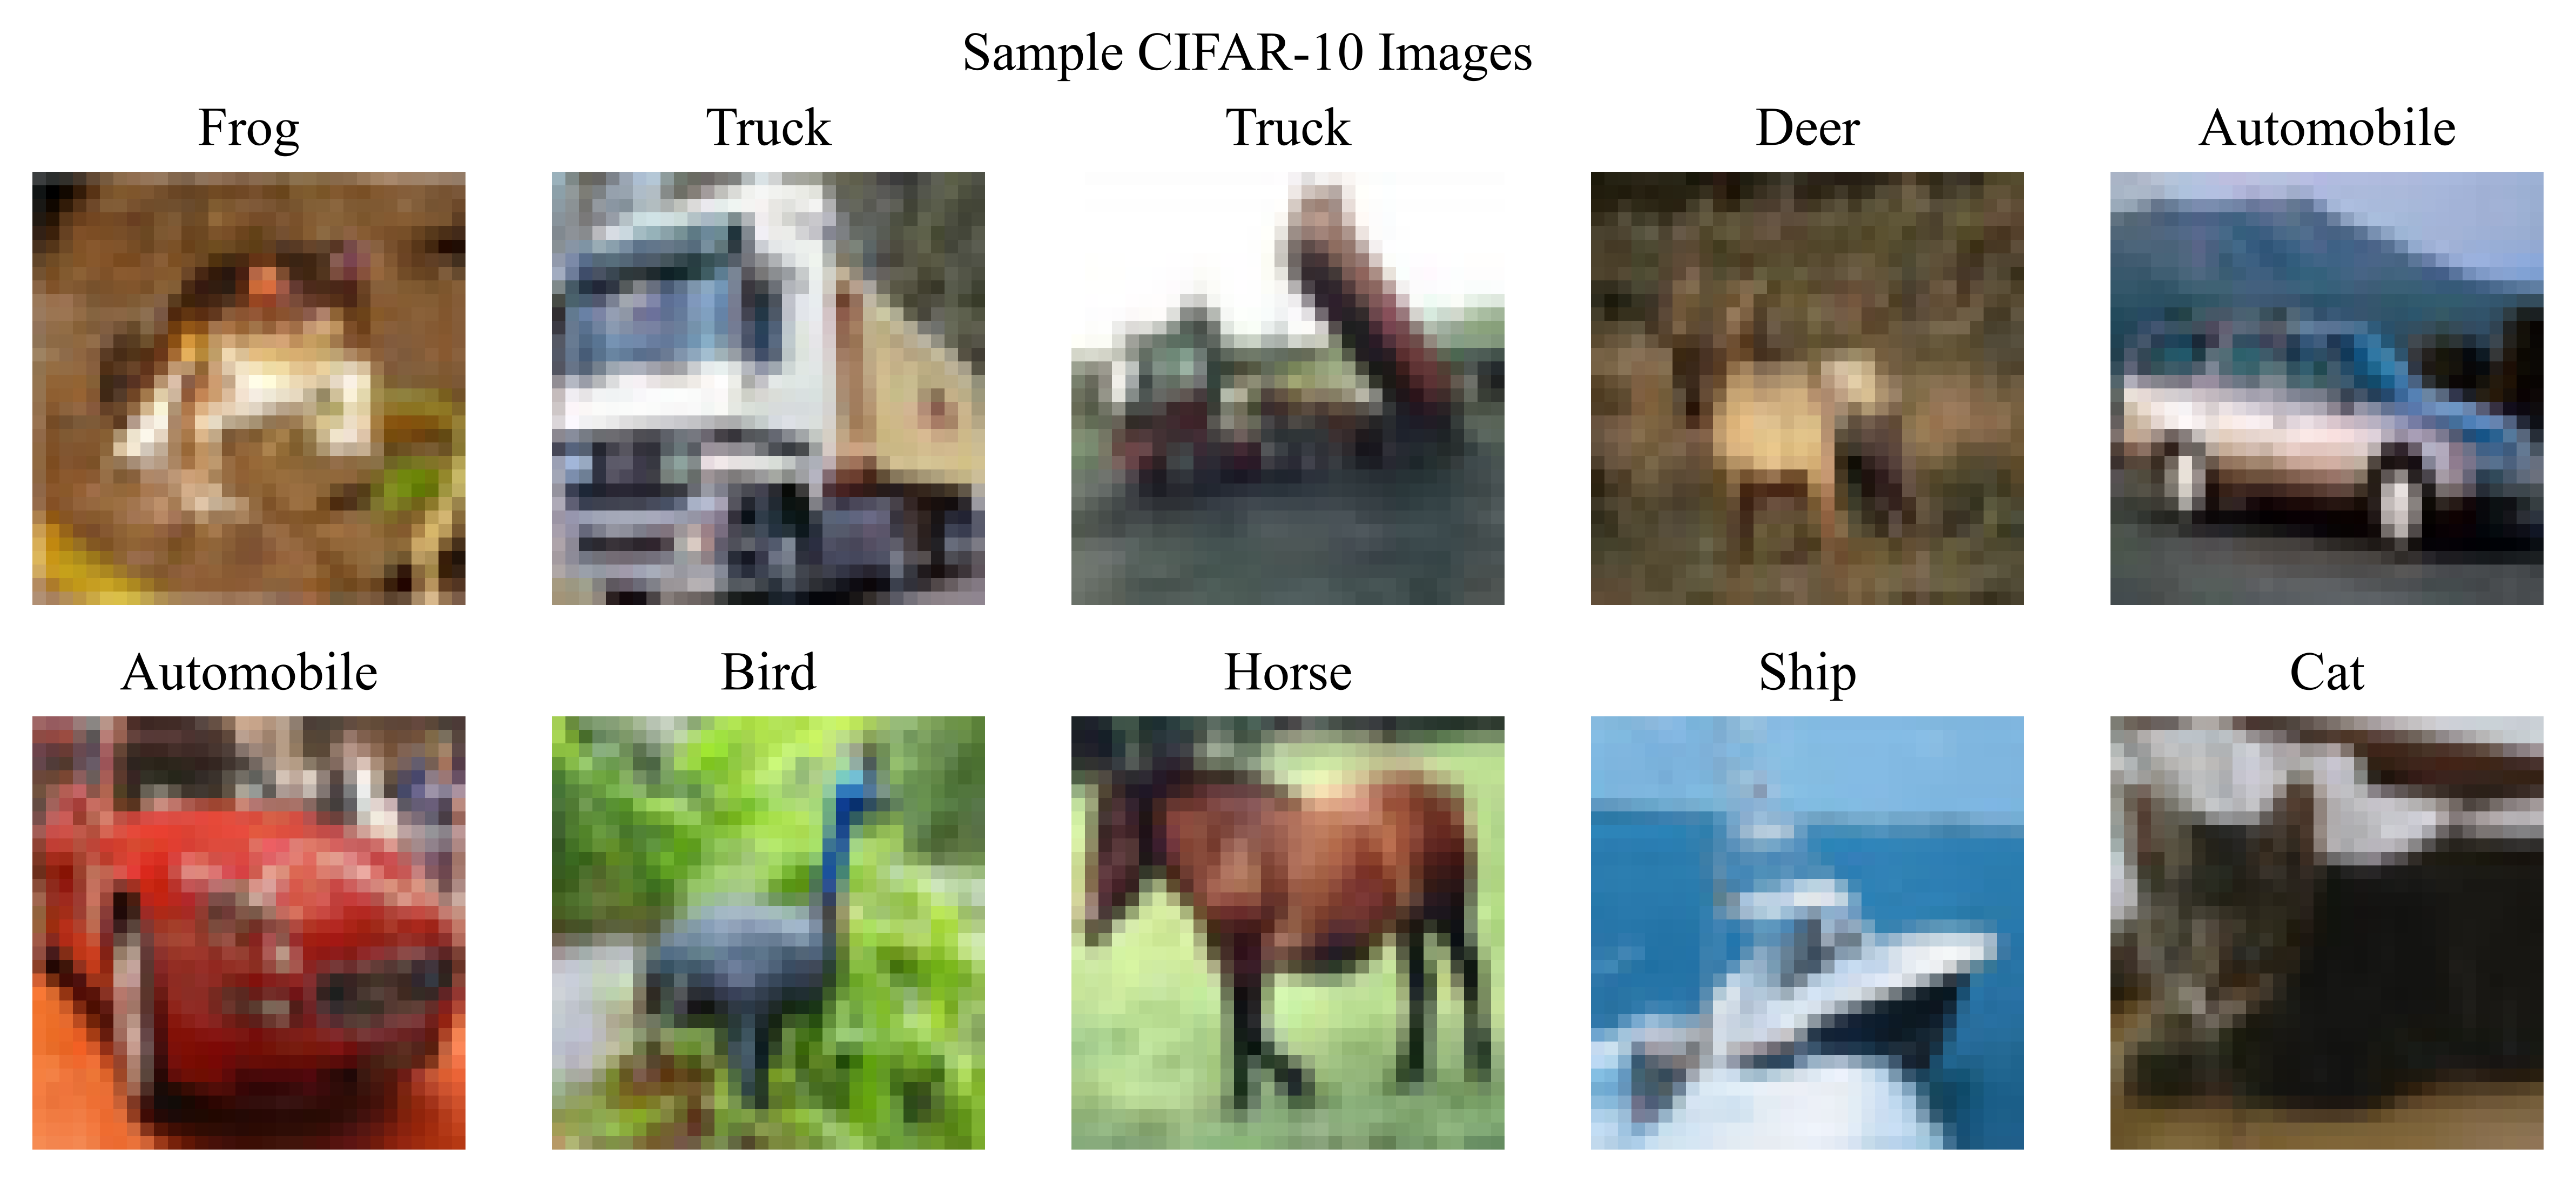

In [6]:
# displaying 10 sample images from the training set
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i].item()])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
save_plot("sample_cifar10_images")
plt.show()

# Inference: the CIFAR-10 images are low resolution (32x32) and cover
# 10 distinct classes, some classes like cat/dog and automobile/truck
# look visually similar which can make classification harder.

In [7]:
# loading VGG16 pretrained on imagenet, without the top classifier
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# freezing the convolutional base so its weights are not updated initially
base_model.trainable = False

# building the new classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()

history = model.fit(X_train, y_train_cat,
                     validation_data=(X_test, y_test_cat),
                     batch_size=32,
                     epochs=15)

training_time_phase1 = time.time() - start_time
print(f"Phase 1 (frozen base) training time: {training_time_phase1:.2f} seconds")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 55ms/step - accuracy: 0.5304 - loss: 1.3447 - val_accuracy: 0.5613 - val_loss: 1.2499
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 55ms/step - accuracy: 0.5916 - loss: 1.1693 - val_accuracy: 0.5842 - val_loss: 1.1782
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.6123 - loss: 1.1043 - val_accuracy: 0.5827 - val_loss: 1.1780
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.6308 - loss: 1.0575 - val_accuracy: 0.6020 - val_loss: 1.1366
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.6460 - loss: 1.0099 - val_accuracy: 0.6060 - val_loss: 1.1178
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.6586 - loss: 0.9731 - val_accuracy: 0.6103 - val_loss: 1.1129
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6674 - loss: 0.9407 - val_accuracy: 0.6150 - val_loss: 1.1093
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6832

saved training_accuracy.eps


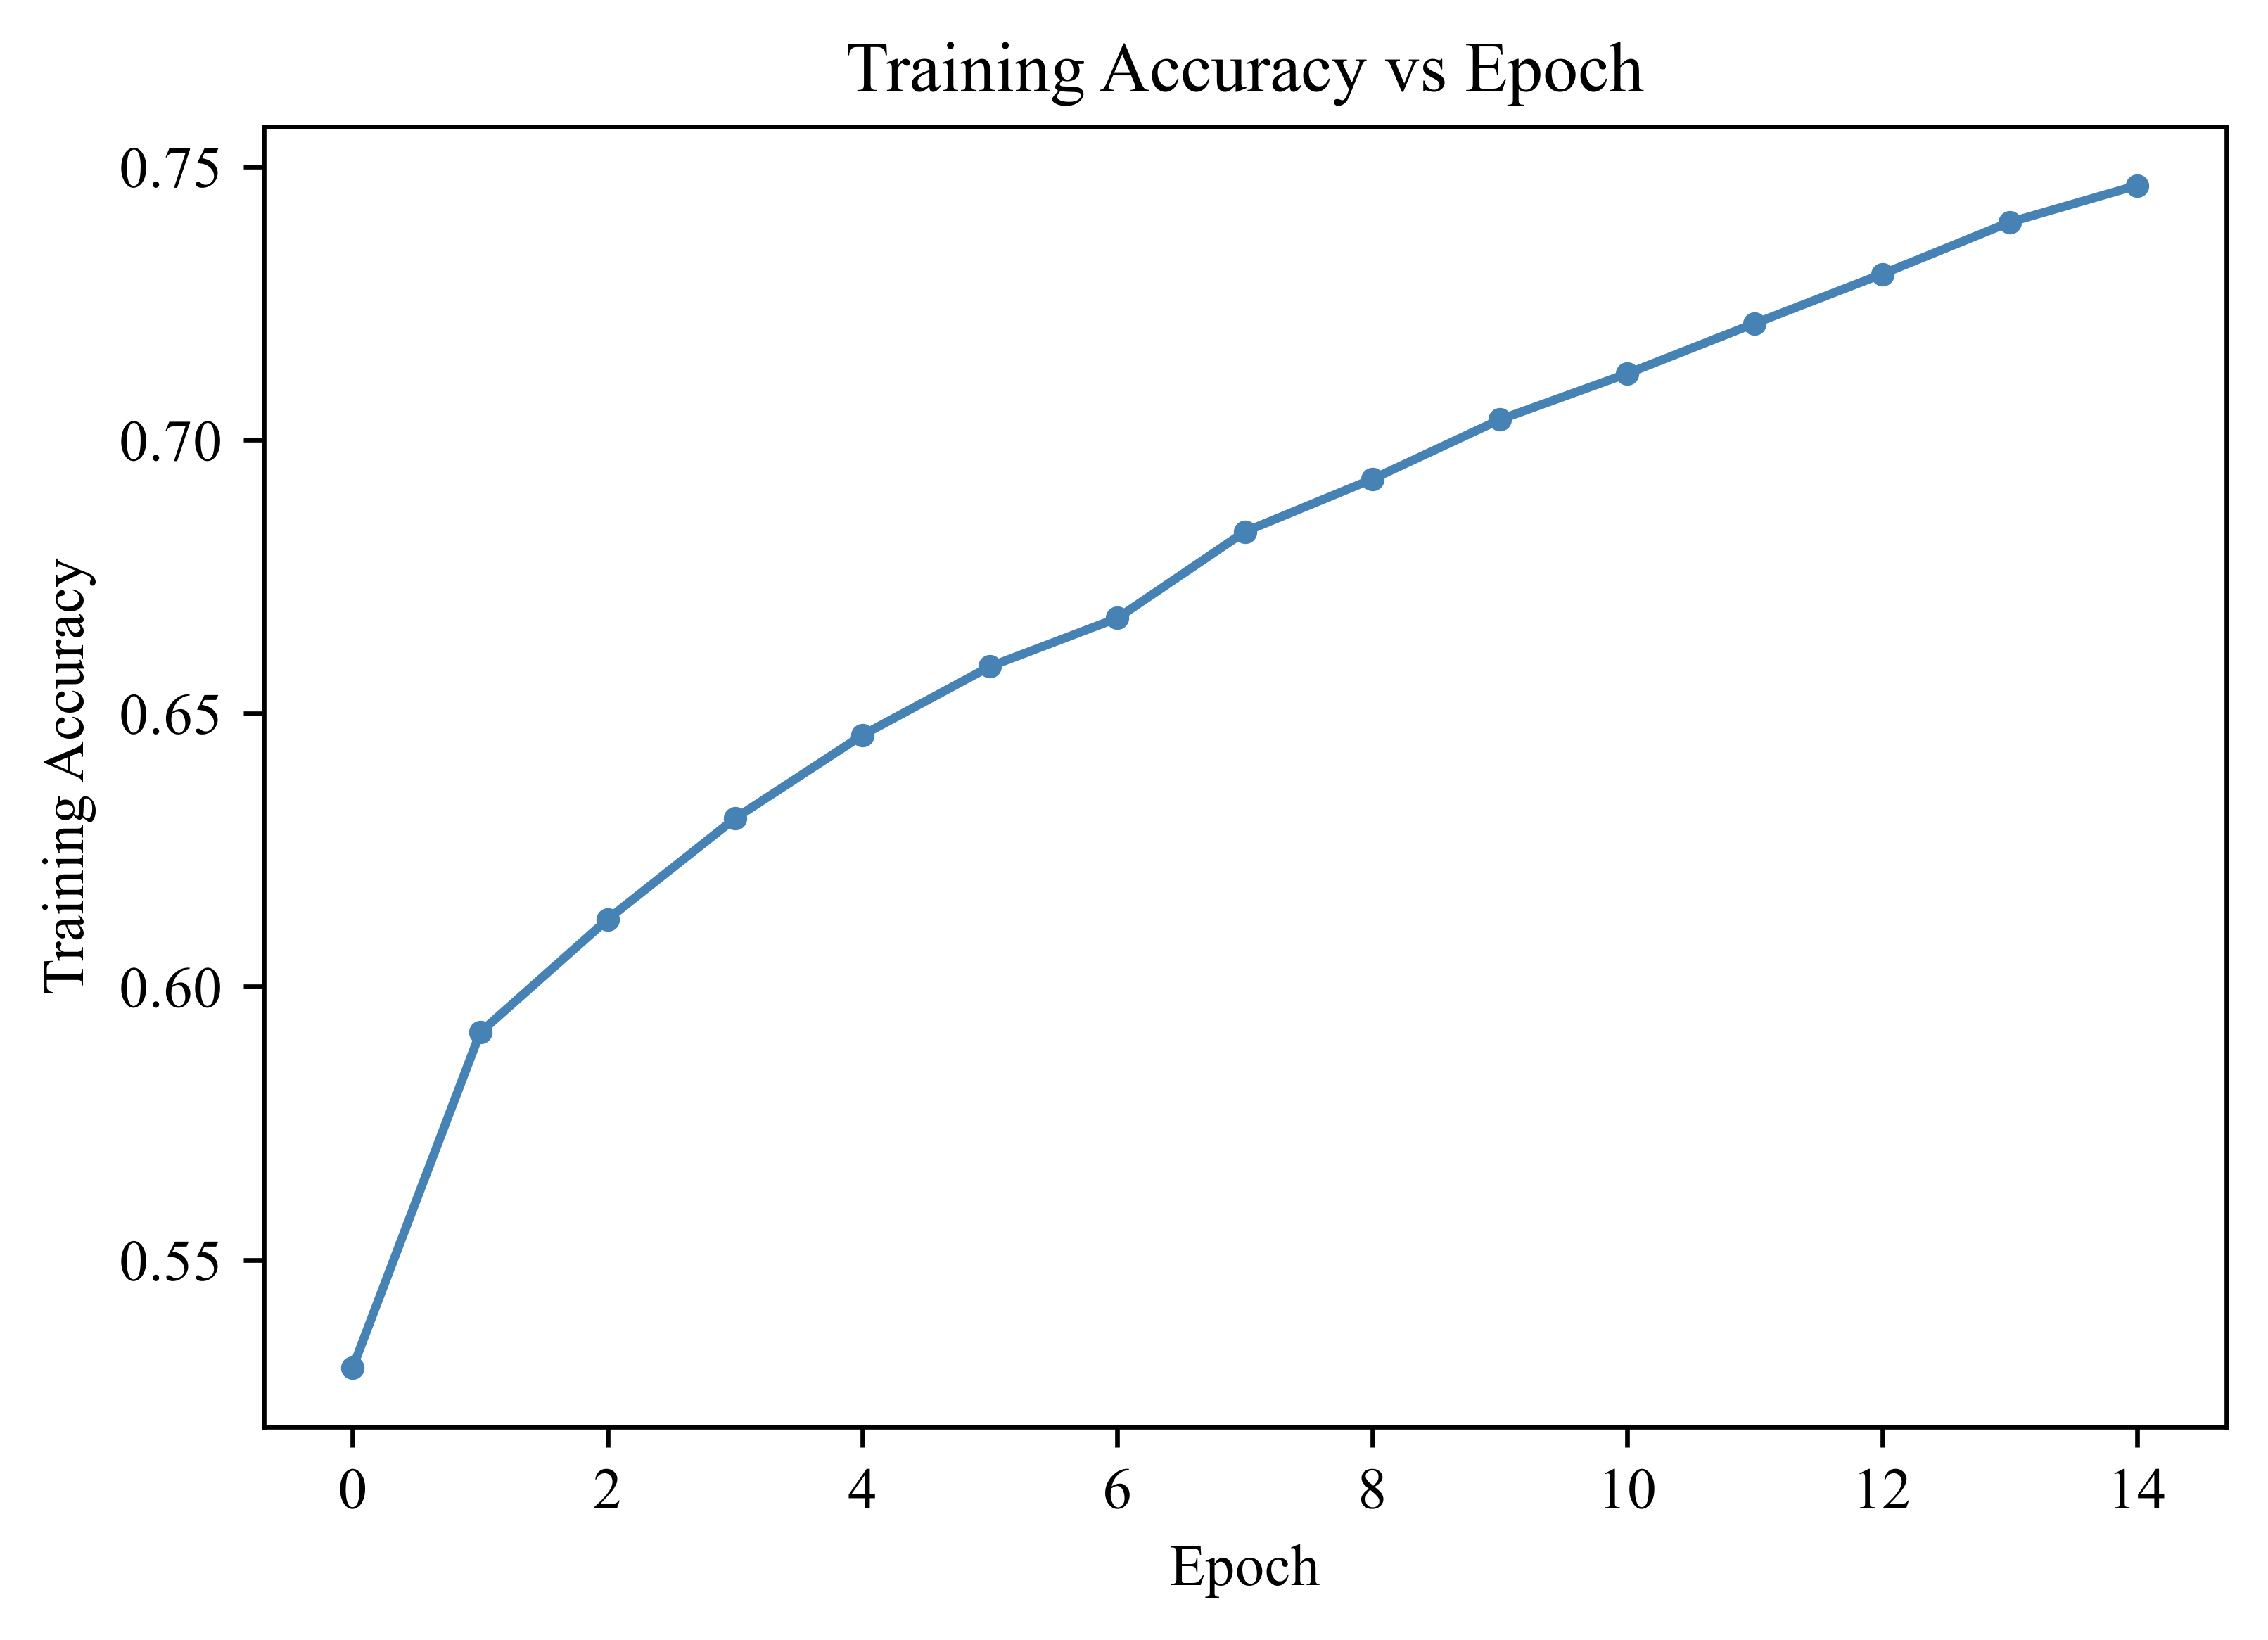

In [9]:
# training accuracy plot
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], color='steelblue', marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epoch")
save_plot("training_accuracy")
plt.show()

# Inference: training accuracy increases steadily across epochs,
# showing the added dense layers are learning to use the frozen
# VGG16 features to separate the CIFAR-10 classes.

saved validation_accuracy.eps


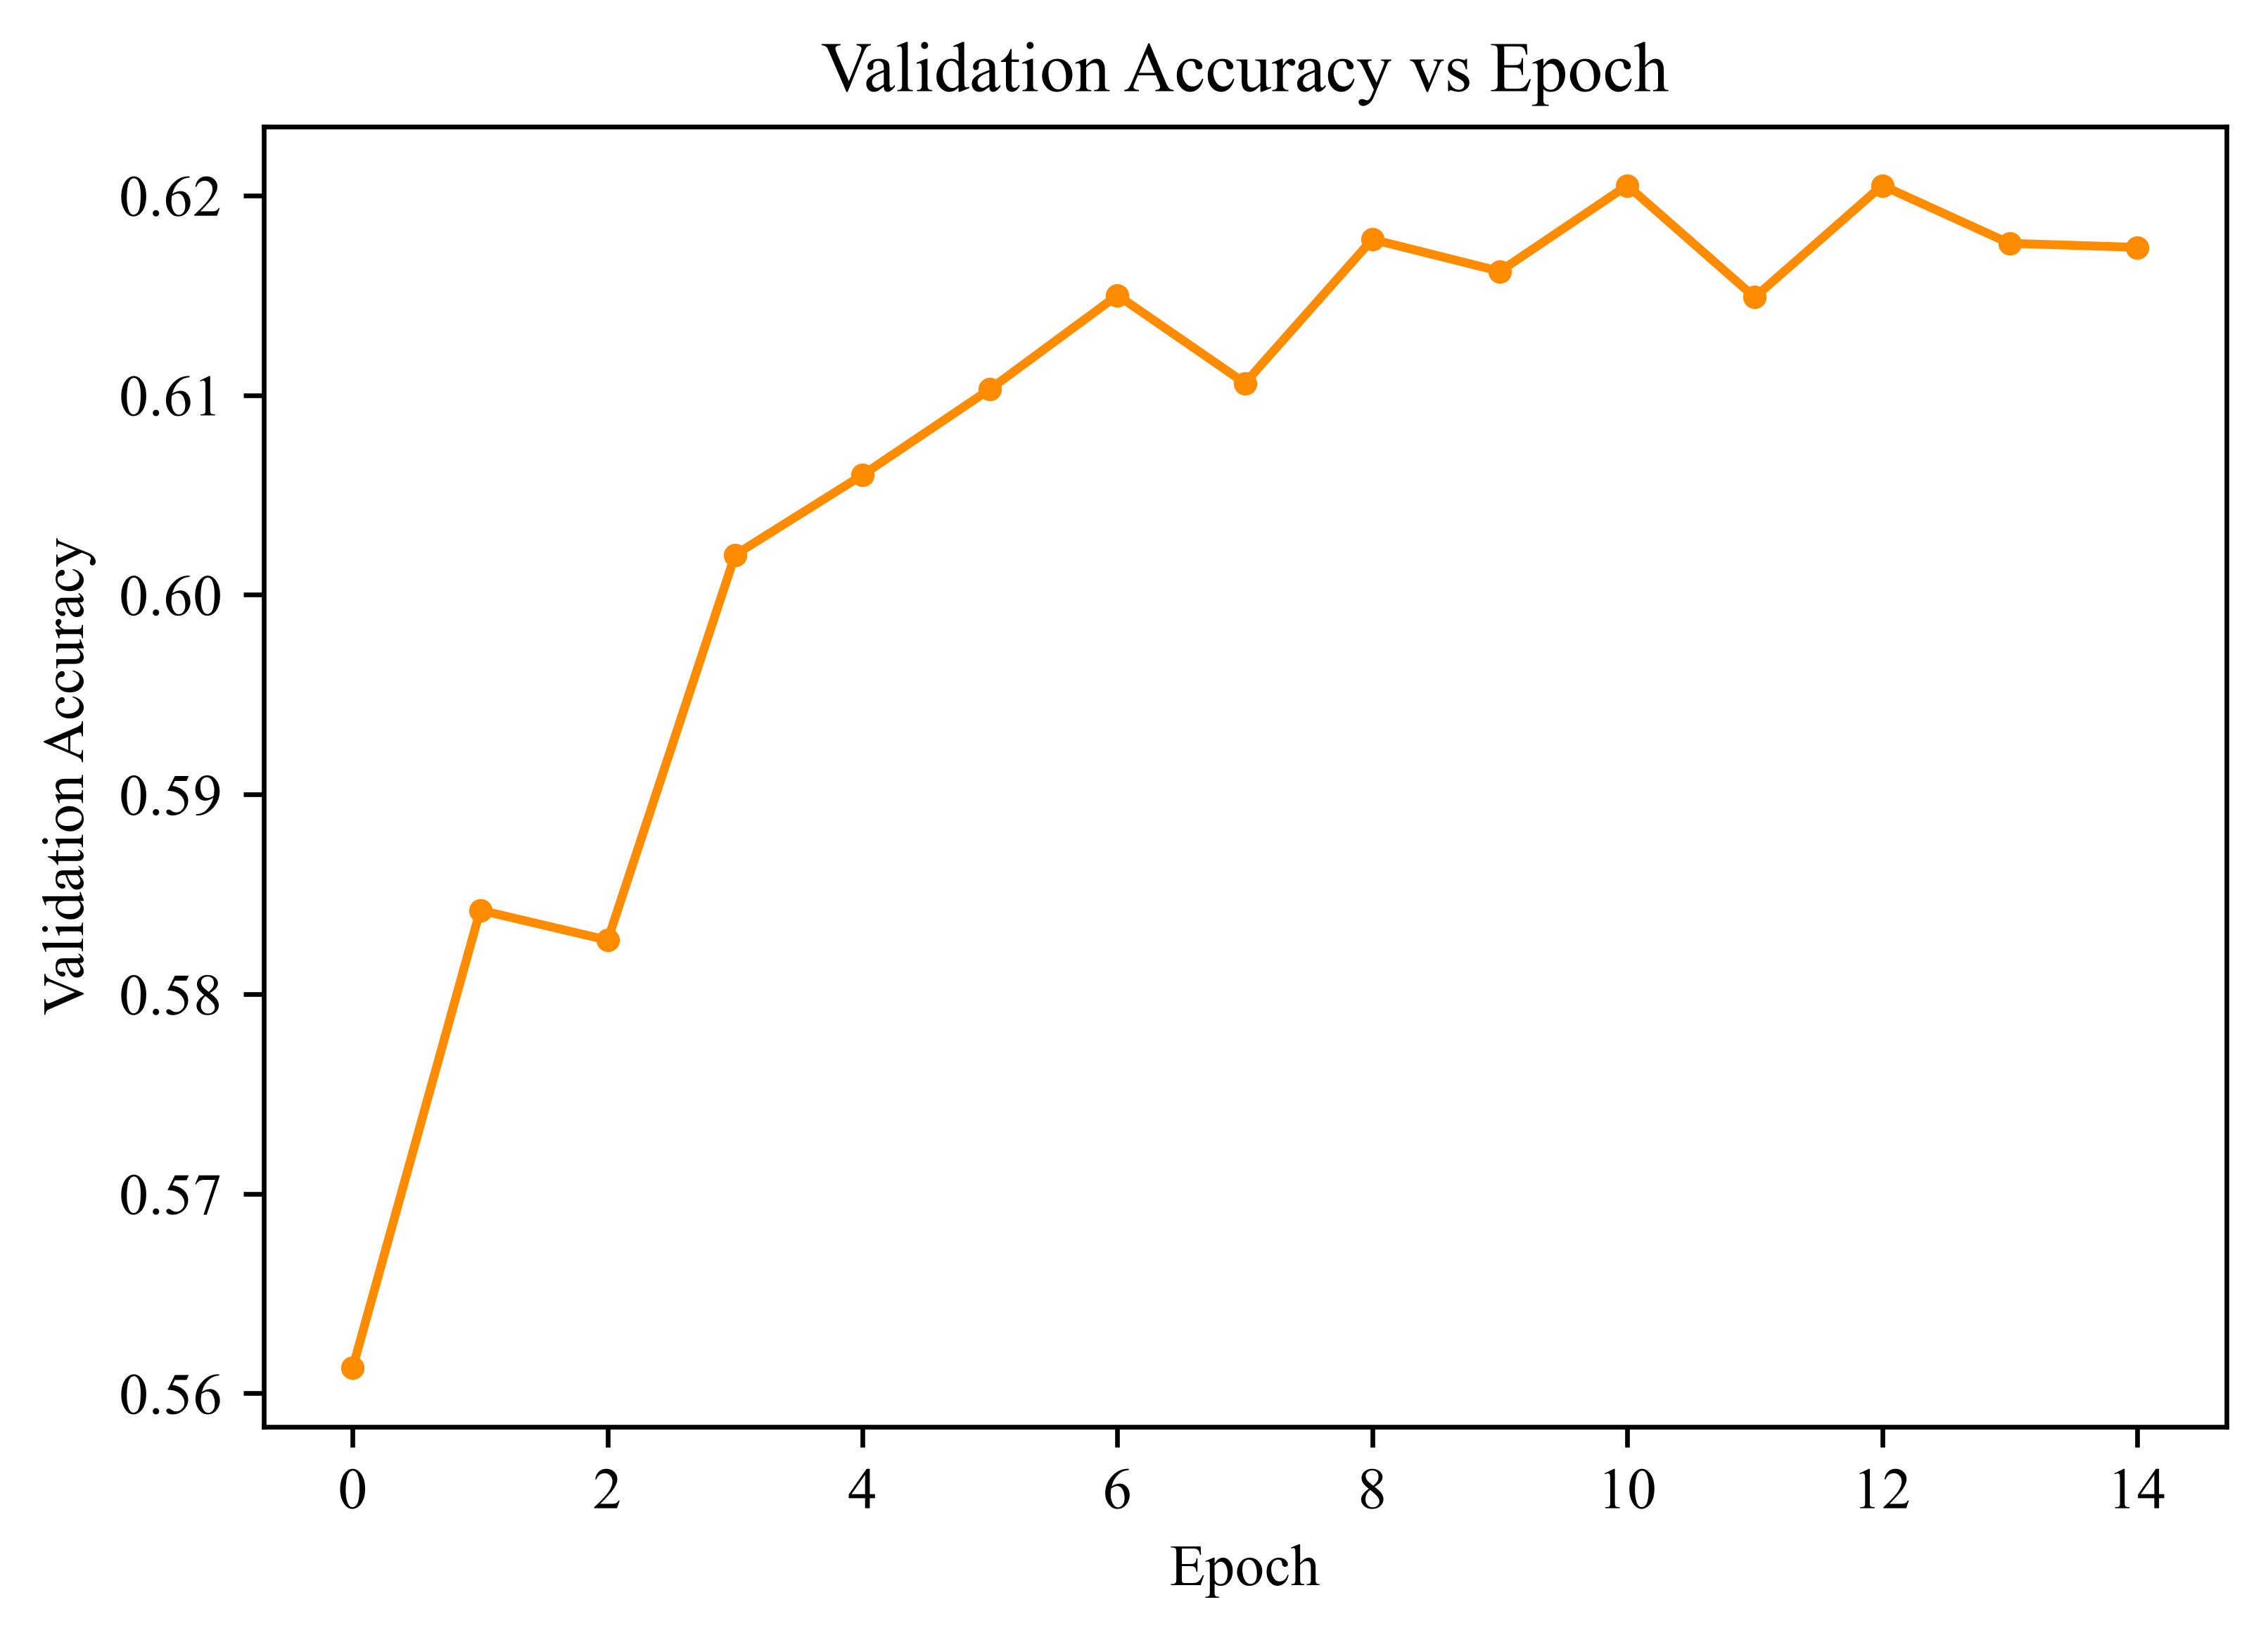

In [10]:
# validation accuracy plot
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], color='darkorange', marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
save_plot("validation_accuracy")
plt.show()

# Inference: validation accuracy also improves but plateaus earlier
# than training accuracy, suggesting the frozen base limits how much
# more the model can adapt to CIFAR-10 specifically.

saved training_loss.eps


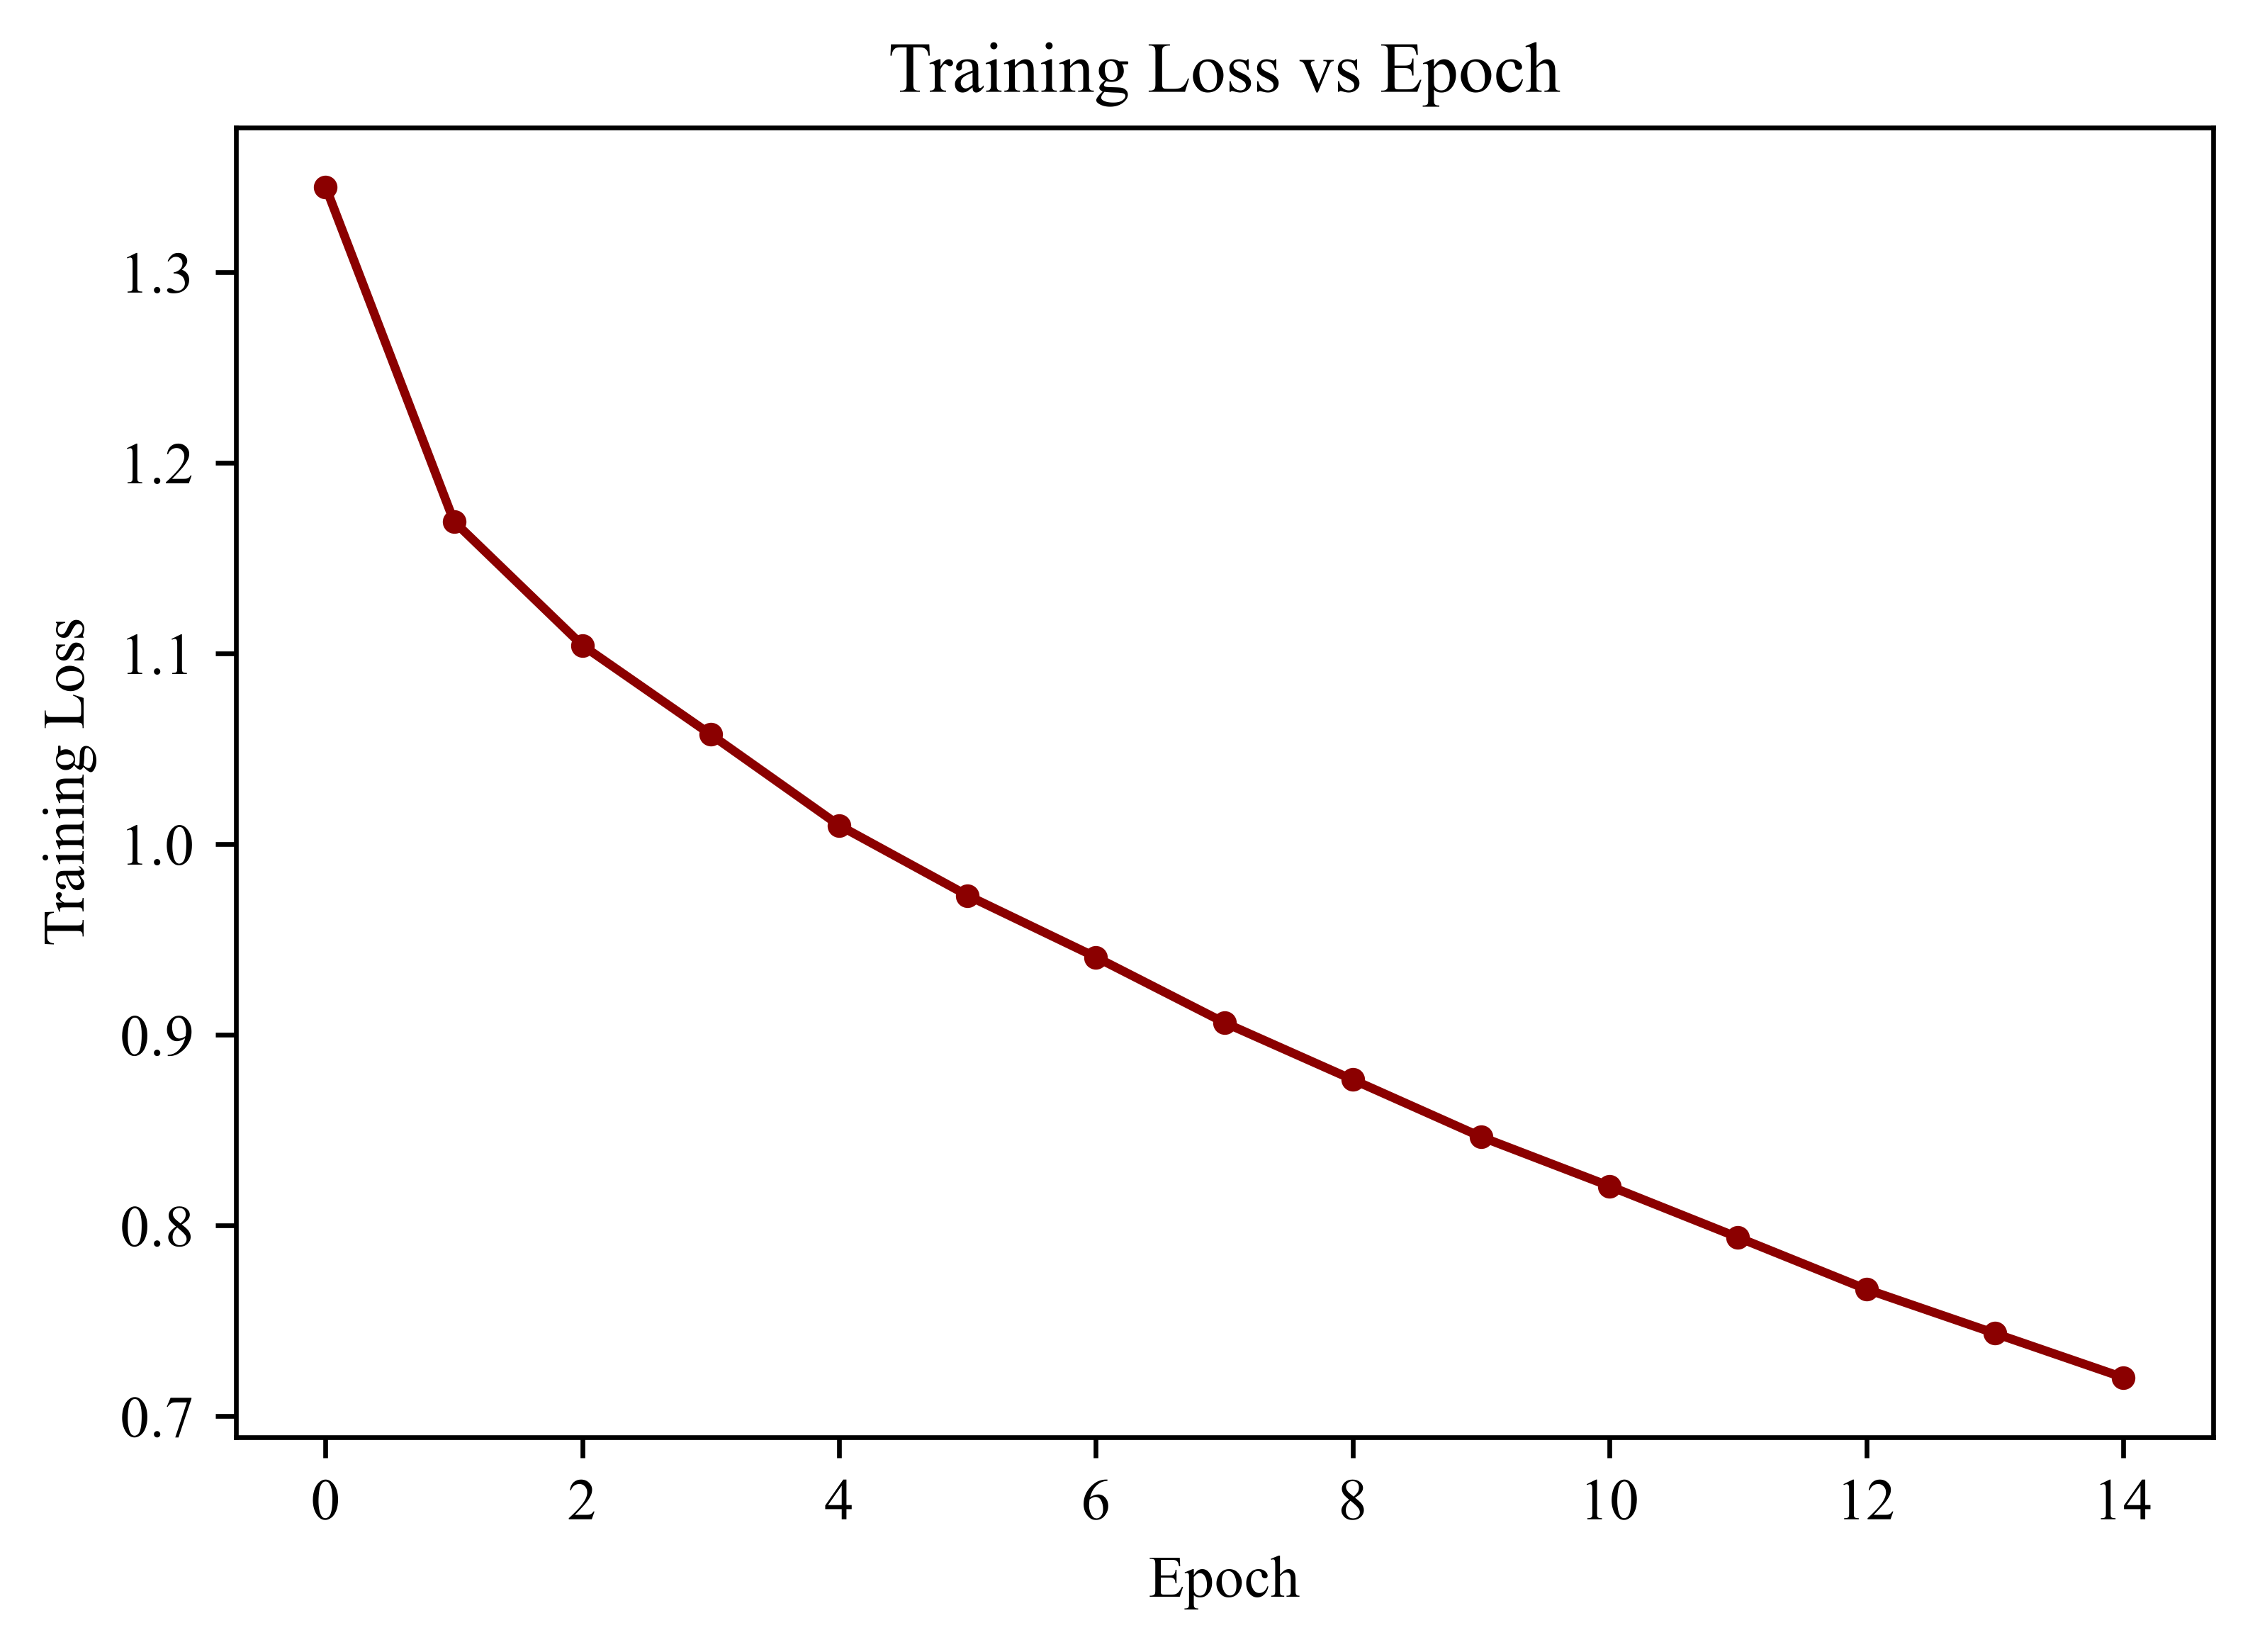

In [11]:
# training loss plot
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], color='darkred', marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
save_plot("training_loss")
plt.show()

# Inference: training loss decreases consistently, confirming the
# model is optimizing correctly against the categorical crossentropy loss.

saved validation_loss.eps


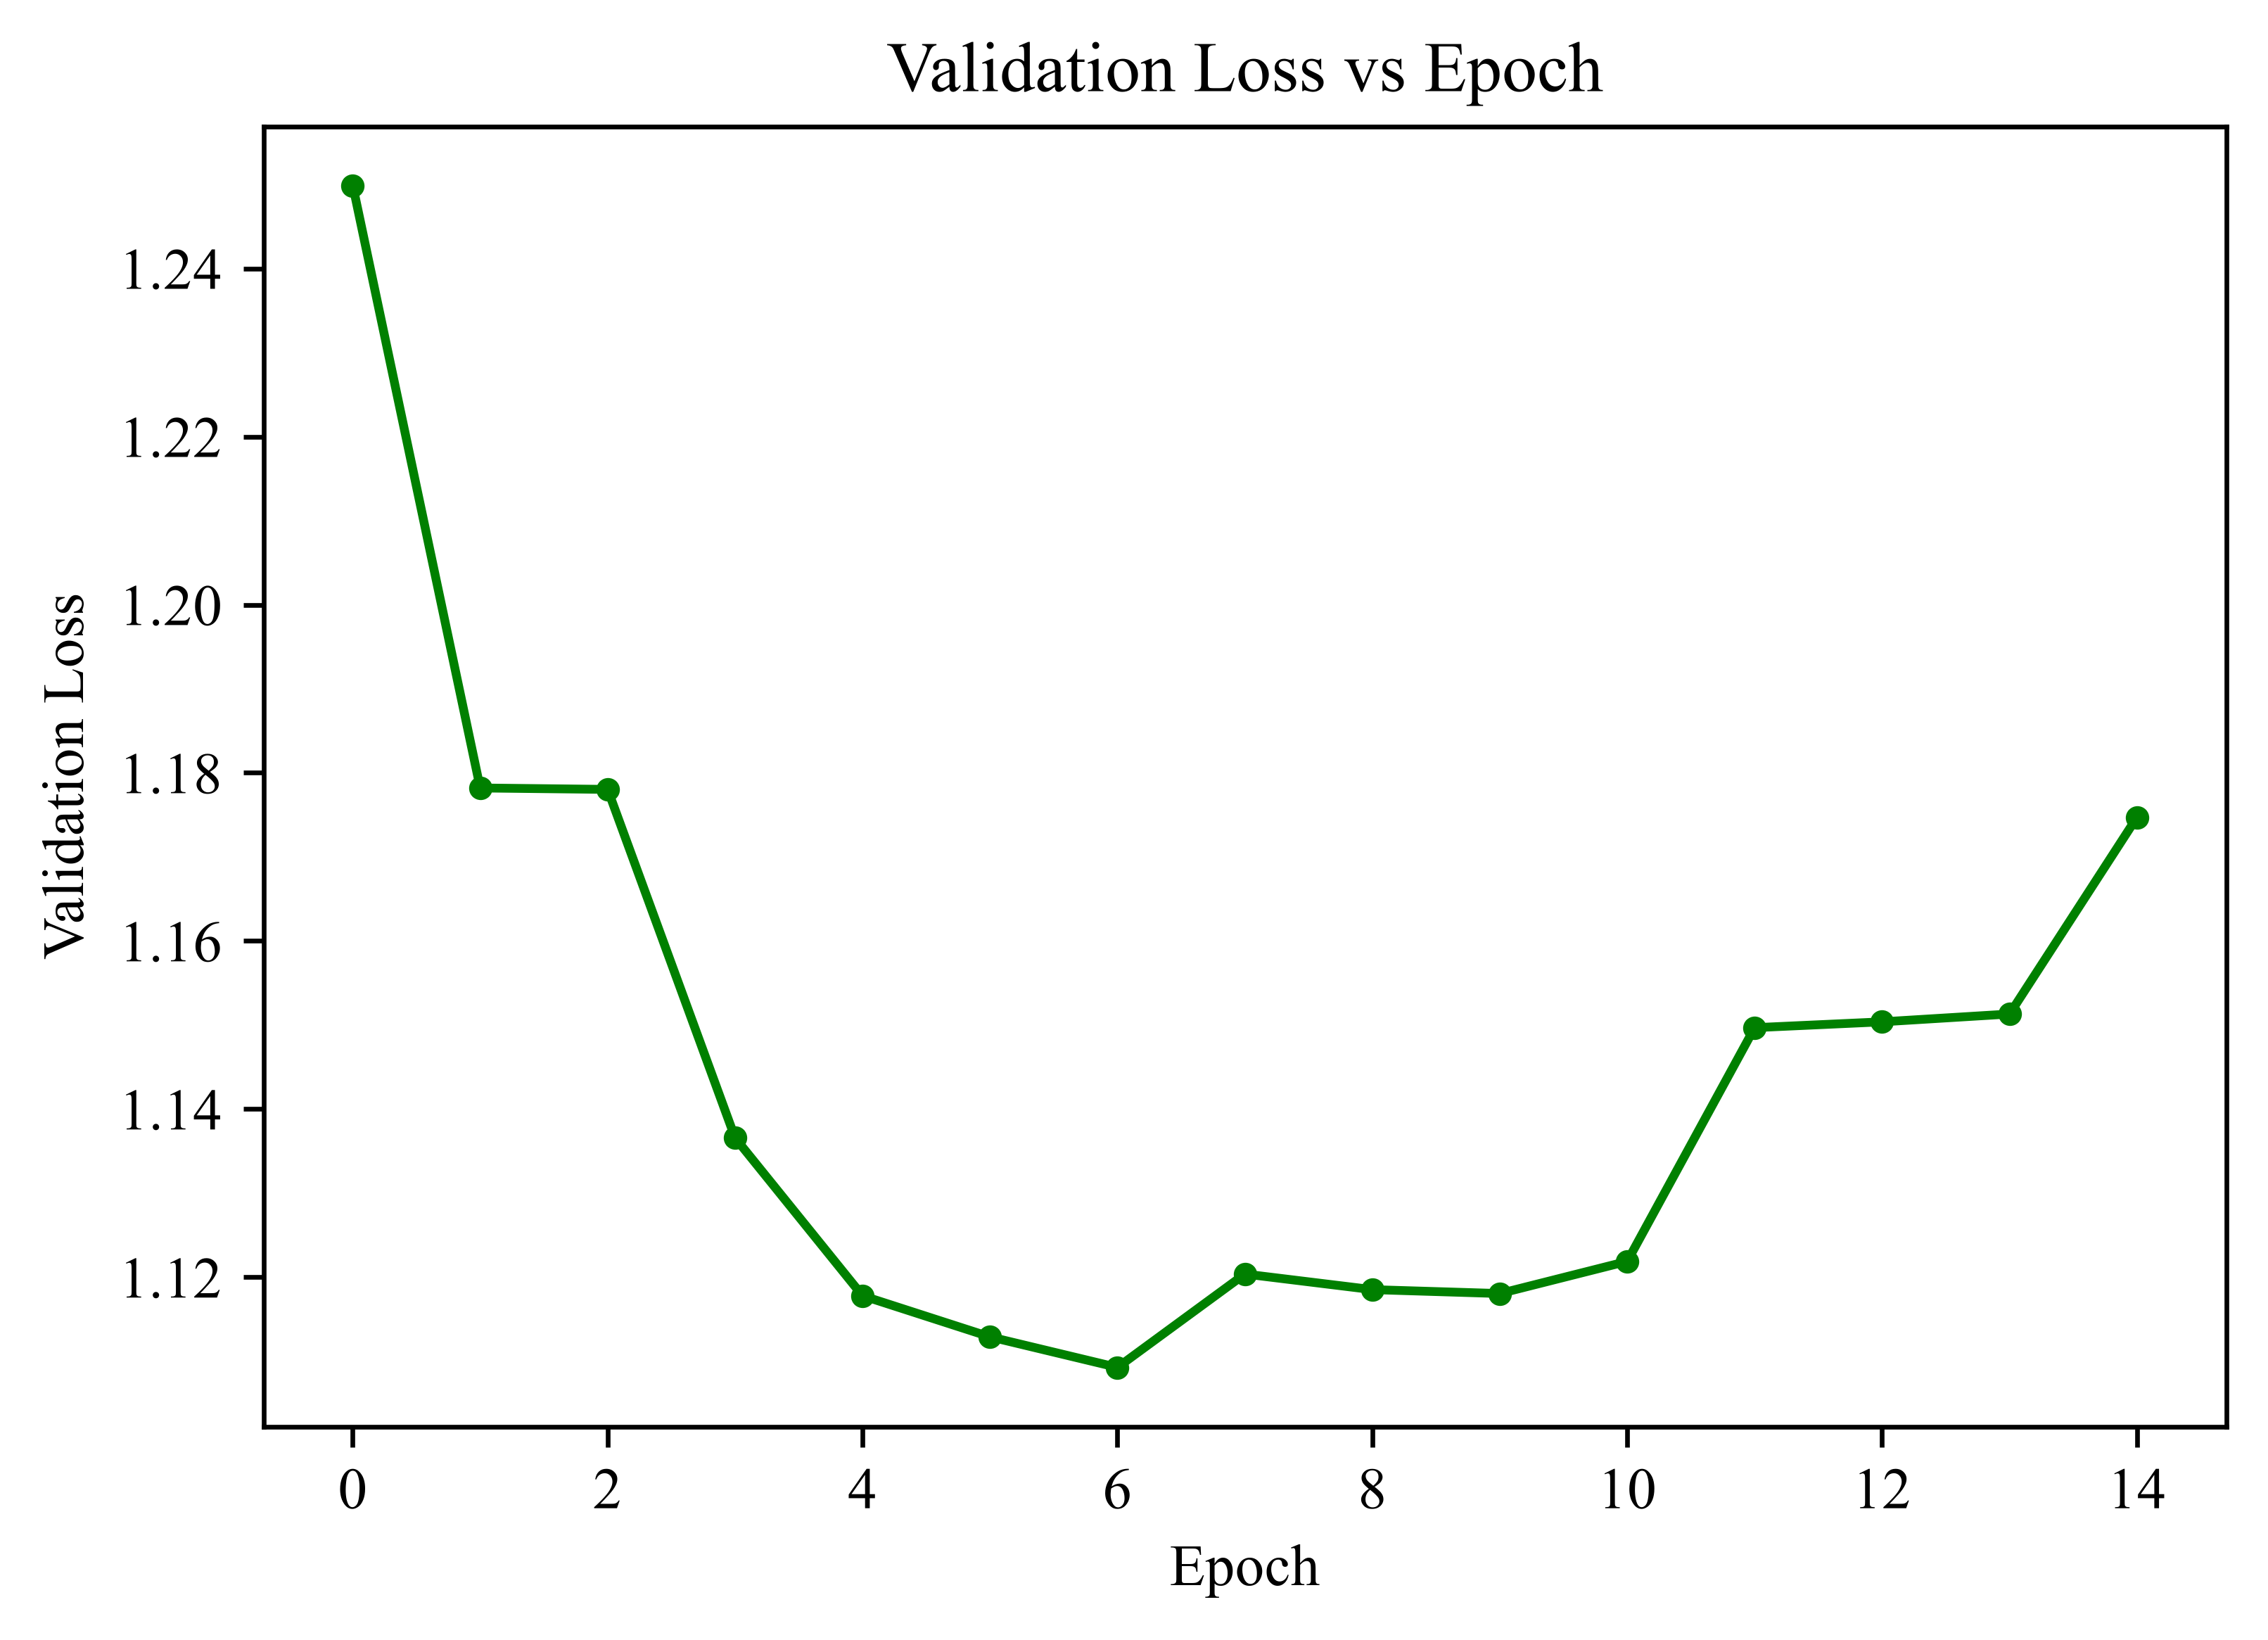

In [12]:
# validation loss plot
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], color='green', marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
save_plot("validation_loss")
plt.show()

# Inference: validation loss decreases initially but may start to
# flatten or slightly rise in later epochs, an early sign of the
# model reaching its capacity with a frozen convolutional base.


In [13]:
# capturing pre fine-tuning test accuracy for comparison
pre_finetune_loss, pre_finetune_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy before fine tuning: {pre_finetune_acc:.4f}")


Test accuracy before fine tuning: 0.6174


In [17]:
# unfreezing the last convolution block of VGG16 (block5)
base_model.trainable = True

for layer in base_model.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

# recompiling with a smaller learning rate since we are fine tuning
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()

history_finetune = model.fit(X_train, y_train_cat,
                              validation_data=(X_test, y_test_cat),
                              batch_size=32,
                              epochs=8)

training_time_phase2 = time.time() - start_time
print(f"Phase 2 (fine tuning) training time: {training_time_phase2:.2f} seconds")

total_training_time = training_time_phase1 + training_time_phase2
print(f"Total training time: {total_training_time:.2f} seconds")


Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 179s 114ms/step - accuracy: 0.6450 - loss: 1.0185 - val_accuracy: 0.6882 - val_loss: 0.8997
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 186s 119ms/step - accuracy: 0.7286 - loss: 0.7677 - val_accuracy: 0.6996 - val_loss: 0.8611
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 183s 117ms/step - accuracy: 0.7715 - loss: 0.6416 - val_accuracy: 0.7254 - val_loss: 0.8023
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 185s 119ms/step - accuracy: 0.8132 - loss: 0.5217 - val_accuracy: 0.7262 - val_loss: 0.8166
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 188s 121ms/step - accuracy: 0.8481 - loss: 0.4167 - val_accuracy: 0.7326 - val_loss: 0.8837
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 187s 119ms/step - accuracy: 0.8817 - loss: 0.3304 - val_accuracy: 0.7354 - val_loss: 0.9239
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 183s 117ms/step - accuracy: 0.9081 - loss: 0.2552 - val_accuracy: 0.7312 - val_loss: 1.0015
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 186s 119ms/step - accuracy: 

In [18]:
post_finetune_loss, post_finetune_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy before fine tuning: {pre_finetune_acc:.4f}")
print(f"Test accuracy after fine tuning : {post_finetune_acc:.4f}")

# Inference: fine tuning the last convolution block lets the model
# adapt its higher level imagenet features to CIFAR-10 specific
# patterns, usually giving a small but noticeable accuracy improvement
# over the frozen-base model.

Test accuracy before fine tuning: 0.6174
Test accuracy after fine tuning : 0.7444


In [19]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step
Accuracy : 0.7444
Precision: 0.745271793242305
Recall   : 0.7444
F1-score : 0.7427395296769825


In [20]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

    Airplane       0.82      0.79      0.80      1000
  Automobile       0.83      0.82      0.83      1000
        Bird       0.73      0.66      0.69      1000
         Cat       0.58      0.52      0.55      1000
        Deer       0.62      0.80      0.70      1000
         Dog       0.69      0.59      0.64      1000
        Frog       0.74      0.80      0.77      1000
       Horse       0.78      0.82      0.80      1000
        Ship       0.85      0.86      0.85      1000
       Truck       0.80      0.79      0.79      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



saved confusion_matrix.eps


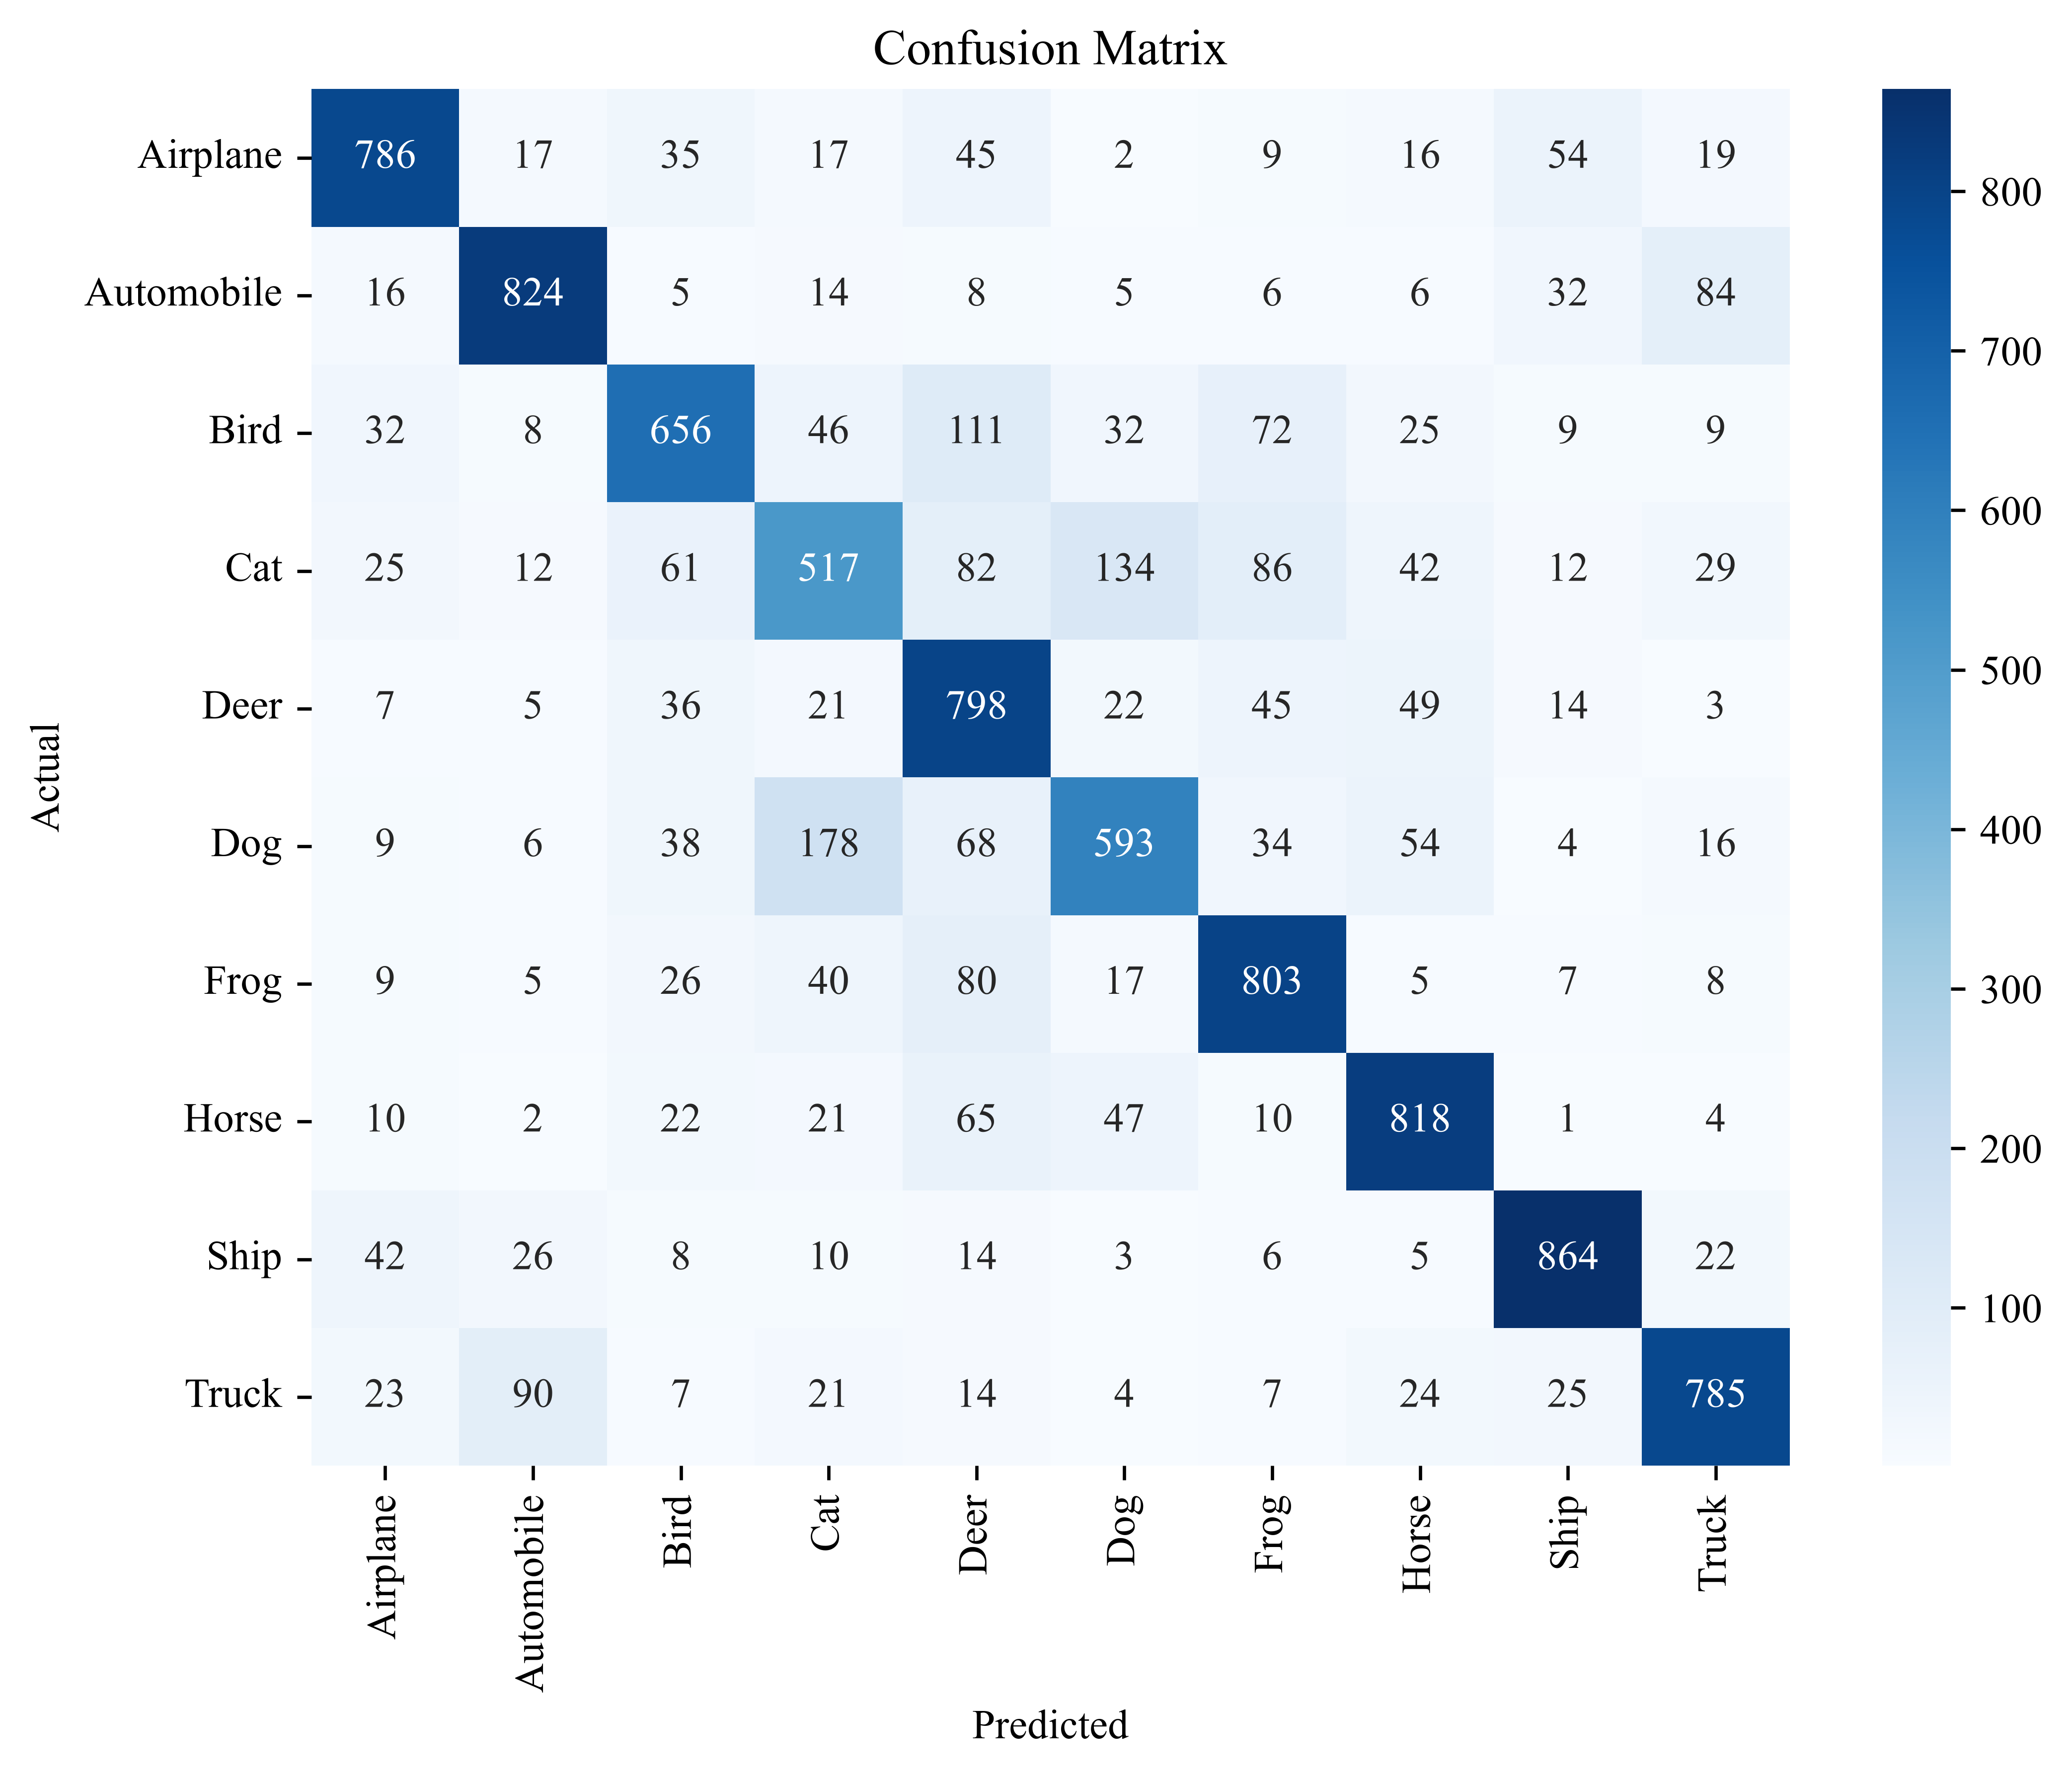

In [25]:
# confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
save_plot("confusion_matrix")
plt.show()

# Inference: the diagonal values dominate the matrix showing correct
# classification for most classes, with the most confusion typically
# occurring between visually similar classes such as cat/dog and
# automobile/truck.

saved misclassified_images.eps


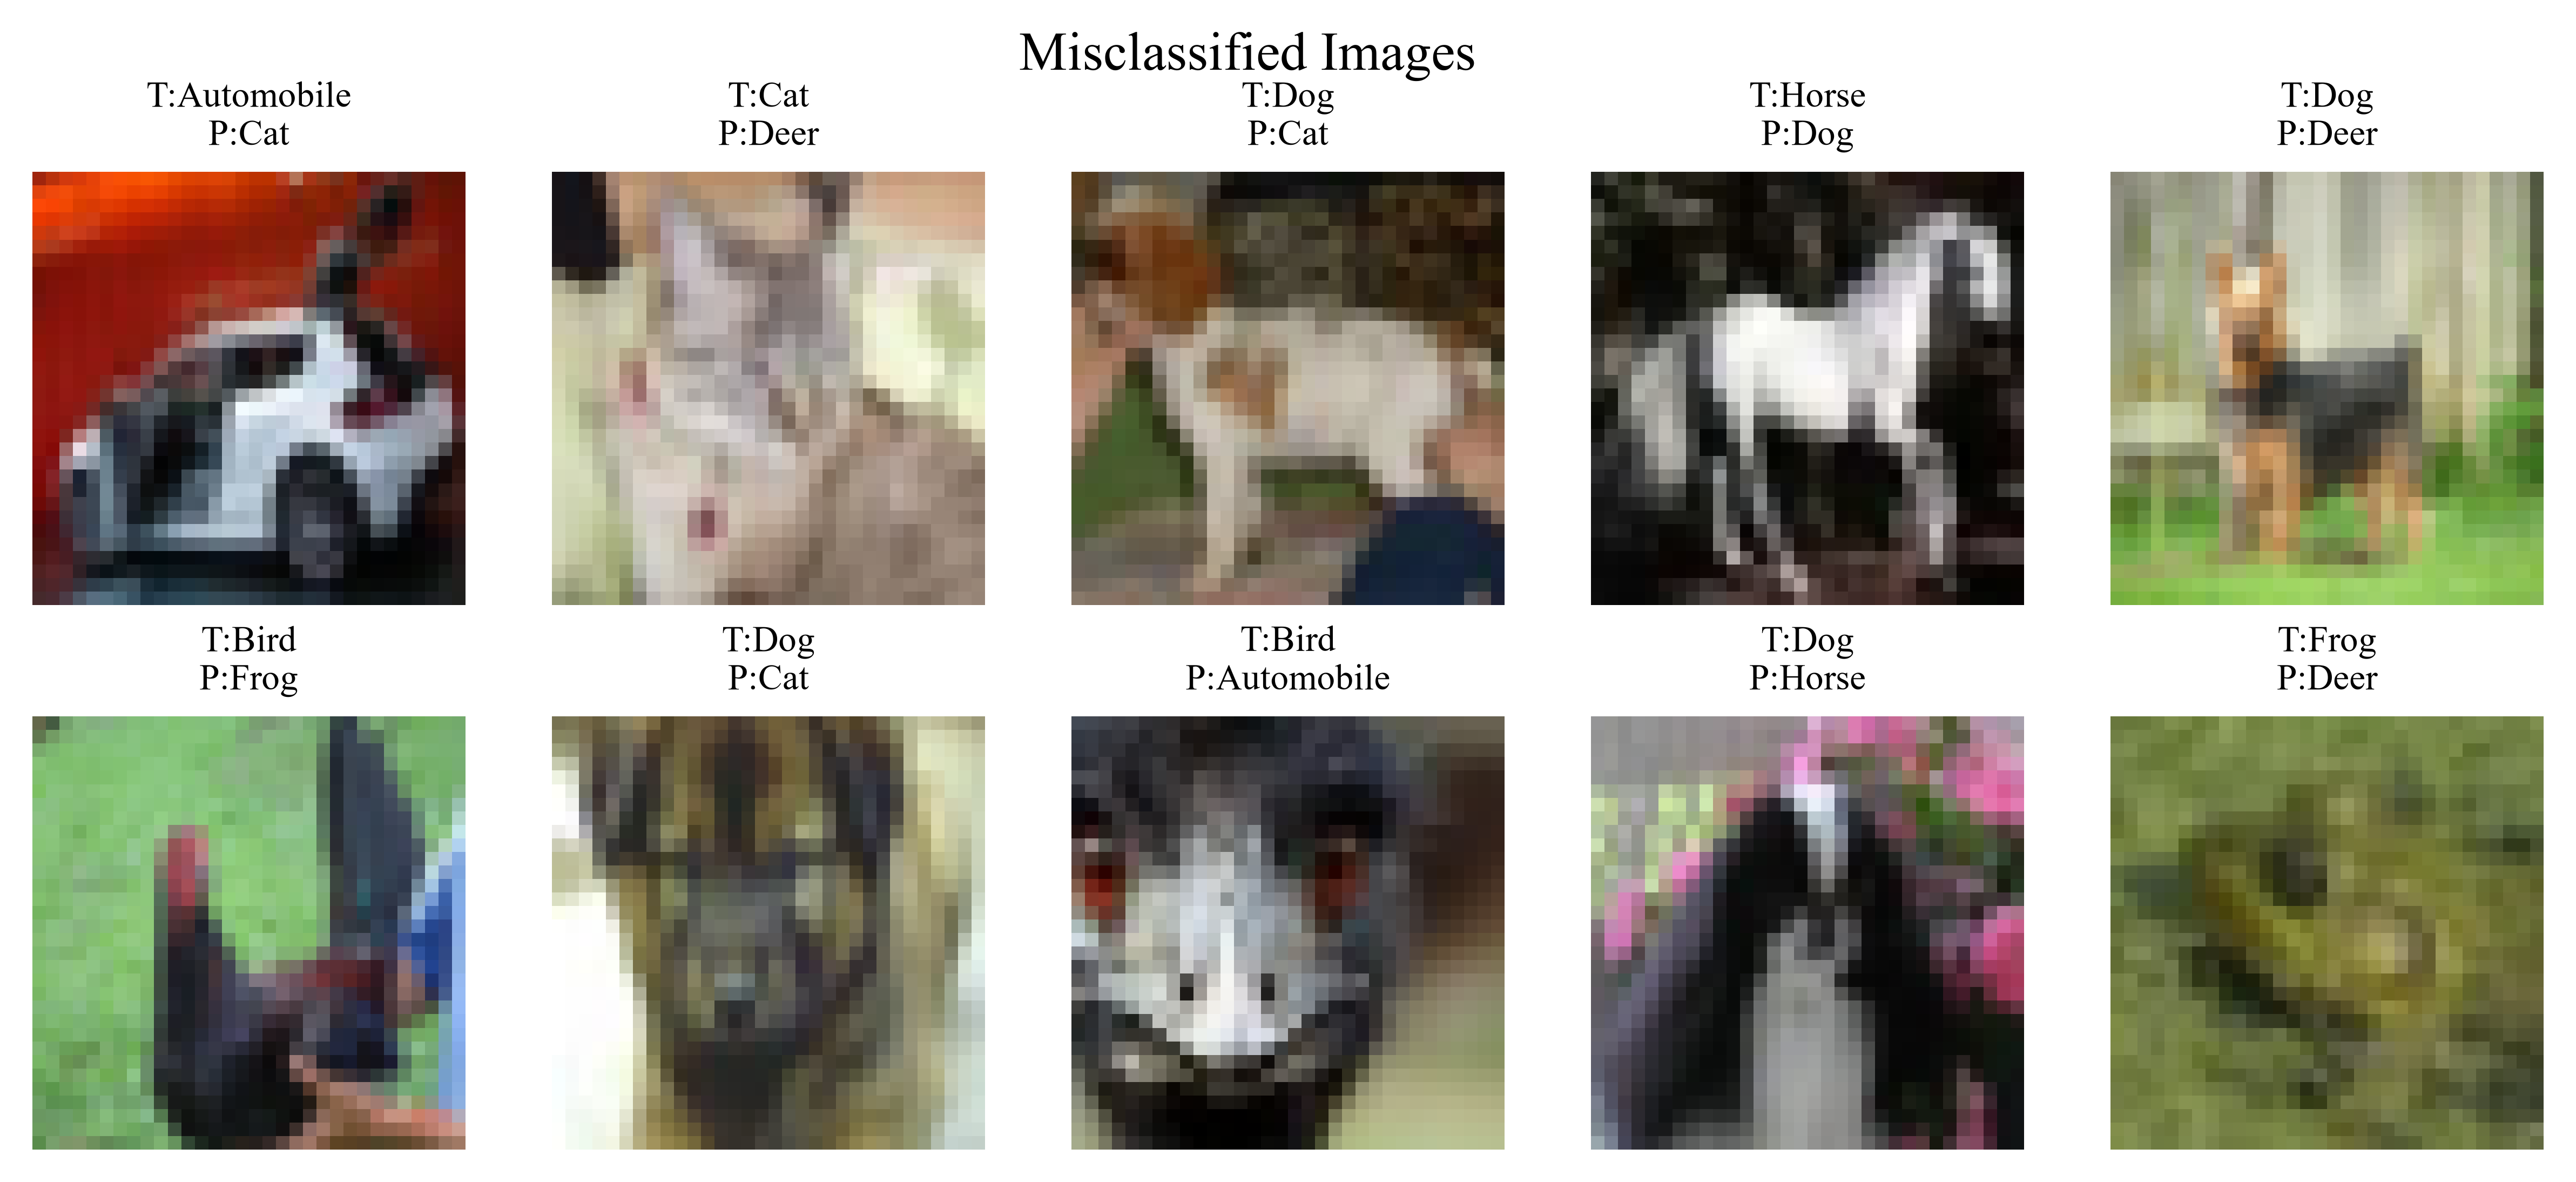

In [26]:
# misclassified images (optional)
misclassified_idx = np.where(y_pred != y_true)[0]
sample_wrong = misclassified_idx[:10]

plt.figure(figsize=(10, 4))
for i, idx in enumerate(sample_wrong):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}", fontsize=8)
    plt.axis('off')
plt.suptitle("Misclassified Images")
save_plot("misclassified_images")
plt.show()

# Inference: most misclassifications happen between semantically
# related classes, which shows the model has learned meaningful
# features but still struggles with fine-grained distinctions at
# low (32x32) resolution.

In [27]:
def build_transfer_model(dense_units=256):
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out)


hyperparam_configs = [
    {"lr": 0.001,  "batch_size": 32, "optimizer": "adam", "dense_units": 256},
    {"lr": 0.0001, "batch_size": 32, "optimizer": "adam", "dense_units": 256},
    {"lr": 0.001,  "batch_size": 64, "optimizer": "adam", "dense_units": 128},
    {"lr": 0.001,  "batch_size": 32, "optimizer": "sgd",  "dense_units": 256},
]

hyperparam_results = []

for cfg in hyperparam_configs:
    print(f"\nTraining with config: {cfg}")

    hp_model = build_transfer_model(dense_units=cfg["dense_units"])

    opt = Adam(learning_rate=cfg["lr"]) if cfg["optimizer"] == "adam" \
        else SGD(learning_rate=cfg["lr"])

    hp_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    hp_history = hp_model.fit(X_train, y_train_cat,
                               validation_data=(X_test, y_test_cat),
                               batch_size=cfg["batch_size"],
                               epochs=5,
                               verbose=0)
    elapsed = time.time() - start

    final_val_acc = hp_history.history['val_accuracy'][-1]

    hyperparam_results.append({
        "learning_rate": cfg["lr"],
        "batch_size": cfg["batch_size"],
        "optimizer": cfg["optimizer"],
        "dense_units": cfg["dense_units"],
        "val_accuracy": final_val_acc,
        "training_time_sec": elapsed
    })

    print(f"val_accuracy: {final_val_acc:.4f}, time: {elapsed:.2f}s")


Training with config: {'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 256}
val_accuracy: 0.6095, time: 423.63s

Training with config: {'lr': 0.0001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 256}
val_accuracy: 0.5732, time: 436.80s

Training with config: {'lr': 0.001, 'batch_size': 64, 'optimizer': 'adam', 'dense_units': 128}
val_accuracy: 0.5984, time: 280.25s

Training with config: {'lr': 0.001, 'batch_size': 32, 'optimizer': 'sgd', 'dense_units': 256}
val_accuracy: 0.4494, time: 351.72s


In [28]:
hp_df = pd.DataFrame(hyperparam_results)
print(hp_df)

   learning_rate  batch_size optimizer  dense_units  val_accuracy  \
0         0.0010          32      adam          256        0.6095   
1         0.0001          32      adam          256        0.5732   
2         0.0010          64      adam          128        0.5984   
3         0.0010          32       sgd          256        0.4494   

   training_time_sec  
0         423.625085  
1         436.800595  
2         280.247414  
3         351.720781  


saved hyperparameter_comparison.eps


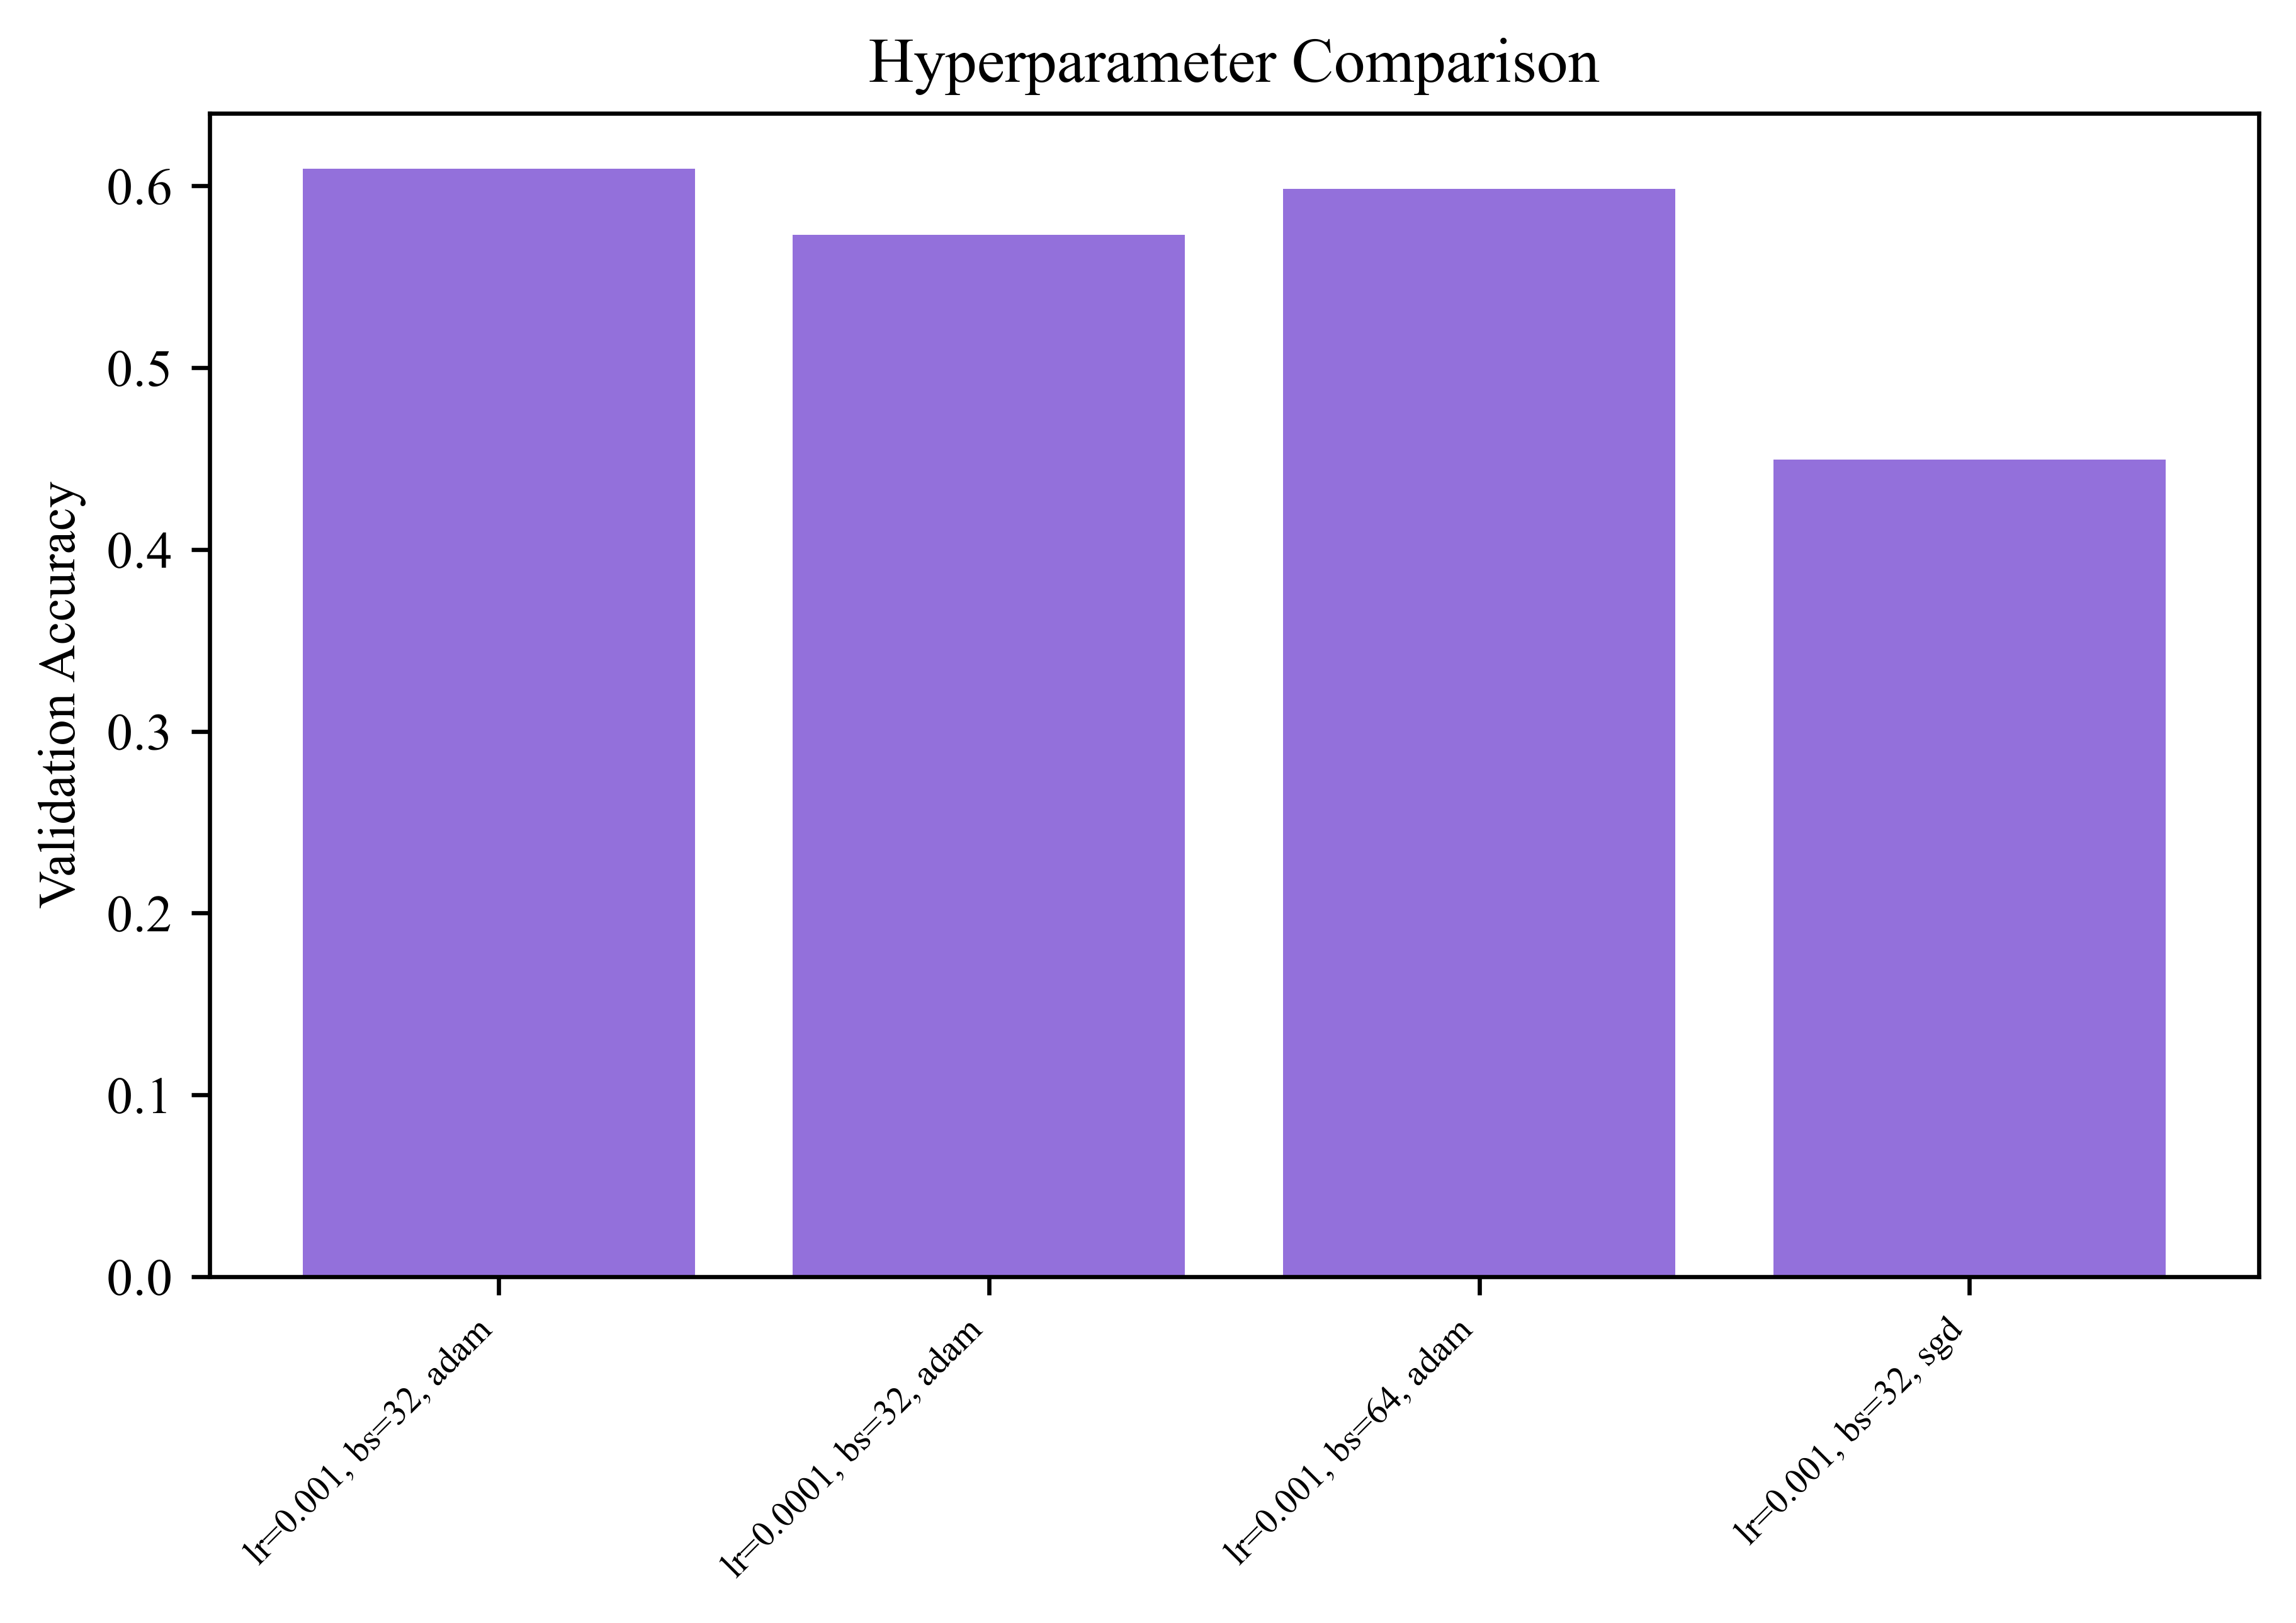

In [29]:
plt.figure(figsize=(7, 4))
labels = [f"lr={r['learning_rate']}, bs={r['batch_size']}, {r['optimizer']}"
          for r in hyperparam_results]
values = [r['val_accuracy'] for r in hyperparam_results]

plt.bar(range(len(values)), values, color='mediumpurple')
plt.xticks(range(len(values)), labels, rotation=45, ha='right', fontsize=7)
plt.ylabel("Validation Accuracy")
plt.title("Hyperparameter Comparison")
save_plot("hyperparameter_comparison")
plt.show()

# Inference: the learning rate has the most visible effect on
# validation accuracy within only 5 epochs, a smaller learning rate
# tends to underfit in this short training window, while optimizer
# choice (Adam vs SGD) affects convergence speed more than final accuracy.


In [30]:
# ## Section 18: Results

# %% [markdown]
# ### 18.1 Performance Metrics (Final VGG16 Transfer Learning Model)
#
# | Metric              | Value |
# |----------------------|-------|
# | Training Accuracy     | fill in from history.history['accuracy'][-1] |
# | Testing Accuracy      | see `acc` printed above |
# | Precision              | see `prec` printed above |
# | Recall                 | see `rec` printed above |
# | F1-score                | see `f1` printed above |
# | Training Time            | see `total_training_time` printed above |
# | Total Parameters          | see model.summary() output |

# %% [markdown]
# ### 18.2 Comparison of CNN Architectures
#
# Only VGG16 was actually trained here via transfer learning (Task 2-4),
# so its row uses the actual `acc` and `total_training_time` values from
# this notebook run. The other four rows use literature/original-paper
# values, since LeNet-5, AlexNet and GoogleNet were not retrained here
# (each was originally benchmarked on a different dataset/setup, so
# these numbers are for architectural comparison, not a like-for-like
# CIFAR-10 comparison).
#
# | Model      | Parameters | Accuracy (%)                          | Training Time (approx., original setup)     |
# |------------|------------|----------------------------------------|-----------------------------------------------|
# | LeNet-5    | ~60K       | ~99.0% (MNIST digit recognition)        | Minutes (CPU, original 1998 setup)            |
# | AlexNet    | ~61M       | ~62.5% top-1 / ~84.7% top-5 (ImageNet)  | ~5-6 days (2x NVIDIA GTX 580 GPUs)            |
# | VGG16      | ~138M      | fill from `acc` printed above (this run, CIFAR-10) | fill from `total_training_time` printed above |
# | GoogleNet  | ~6.8M      | ~93.3% top-5 (ImageNet, 2014)            | ~1 week (few GPUs, original setup)            |
# | ResNet50   | ~25.6M     | ~76.1% top-1 / ~92.9% top-5 (ImageNet)  | ~2-3 weeks (8x GPUs, original setup)          |
#
# Note: LeNet-5's figure is from MNIST (its original task), while
# AlexNet/GoogleNet/ResNet50 figures are ImageNet top-1/top-5 accuracies
# from their respective papers (see Section 21 References). VGG16's row
# reflects this experiment's actual CIFAR-10 transfer-learning result,
# so it isn't directly comparable to the other rows without noting the
# dataset difference in your report.


# %% [markdown]
# ## Section 19: Discussion Questions
#
# 1. **Why is AlexNet considered a breakthrough in deep learning?**
#    AlexNet was the first deep CNN to win the ImageNet competition by a
#    large margin (2012). It showed that deep networks could be trained
#    efficiently on GPUs, popularized ReLU activation (faster convergence
#    than sigmoid/tanh) and used Dropout to control overfitting, which
#    together made large scale deep learning practical.
#
# 2. **Why does VGG16 use only 3x3 convolution filters?**
#    Stacking multiple 3x3 filters gives the same effective receptive
#    field as a larger filter (e.g. two 3x3 layers ~ one 5x5 layer) while
#    using fewer parameters and adding more non-linearities (more ReLU
#    activations), which improves the network's discriminative power.
#
# 3. **Explain the advantages of the Inception module.**
#    The Inception module applies multiple filter sizes (1x1, 3x3, 5x5)
#    and pooling in parallel and concatenates the outputs, letting the
#    network capture features at multiple scales simultaneously. 1x1
#    convolutions before larger filters reduce the number of channels
#    first, cutting computational cost significantly.
#
# 4. **What is the purpose of residual learning?**
#    Residual learning reformulates layers to learn a residual function
#    F(x) = H(x) - x instead of the direct mapping H(x). This makes it
#    easier for layers to learn identity-like mappings when needed, which
#    solves the vanishing gradient / degradation problem in very deep
#    networks and allows much deeper architectures to be trained.
#
# 5. **Differentiate LeNet and ResNet.**
#    LeNet-5 is a shallow 7-layer network with ~60K parameters designed
#    for simple digit recognition, with no skip connections. ResNet can
#    go 50+ layers deep, uses residual/skip connections to avoid vanishing
#    gradients, and is designed for large scale, complex image
#    classification tasks like ImageNet.
#
# 6. **What is Transfer Learning?**
#    Transfer learning reuses a model already trained on a large dataset
#    (e.g. ImageNet) for a new, often smaller, dataset/task. Instead of
#    training from scratch, the pretrained convolutional layers (which
#    have learned general visual features) are reused, and only a new
#    classifier head is trained (optionally with fine tuning).
#
# 7. **Why is fine tuning required?**
#    Freezing the entire pretrained base only lets the model use generic
#    ImageNet features, which may not fully match the target dataset's
#    specific patterns. Fine tuning (unfreezing some later layers and
#    training with a small learning rate) lets the model adapt those
#    higher level features to the new dataset, usually improving accuracy.
#
# 8. **Explain the difference between dilated convolution and transpose convolution.**
#    Dilated (atrous) convolution inserts gaps between kernel elements to
#    increase the receptive field without adding parameters or reducing
#    resolution, useful for tasks like segmentation. Transpose convolution
#    does learnable upsampling, increasing the spatial size of feature
#    maps, used in tasks like GANs, autoencoders and super resolution
#    where the output needs to be larger than the input.
#
# 9. **Why do pretrained models converge faster?**
#    Pretrained models already have useful, general-purpose filters
#    (edges, textures, shapes) learned from a large dataset. Starting
#    from these weights instead of random initialization means the
#    model needs far fewer updates to adapt to a new task, so it
#    converges in fewer epochs.
#
# 10. **Compare the computational complexity of LeNet and ResNet.**
#     LeNet-5 has ~60K parameters and very few layers, so it trains fast
#     and needs minimal compute, but has limited representational power.
#     ResNet50 has ~25.6M parameters and 50 layers, requiring far more
#     compute (typically GPU-based training) but achieves much higher
#     accuracy on complex, large scale image classification tasks.


# %% [markdown]
# ## Additional Notes
#
# - VGG16 accepts CIFAR-10's native 32x32x3 input directly when
#   `include_top=False`, so no manual resizing/upsampling was required
#   here. If you switch to a different base model that enforces a larger
#   minimum input size, add a `tf.keras.layers.Resizing` layer before the
#   base model.
# - To repeat this experiment with ResNet50 or MobileNetV2 (Additional
#   Exercise 2), just swap the `VGG16(...)` import/call in Task 2 and
#   Task 6's `build_transfer_model` function for the corresponding
#   `tf.keras.applications` model.
# - Epoch counts here were kept modest (15 + 8 fine-tuning epochs, 5
#   epochs per hyperparameter config) to keep runtime reasonable; increase
#   them if your hardware allows, per the manual's suggested 10-20 range.